In [3]:
import numpy as np
import json
from concurrent.futures import ThreadPoolExecutor, as_completed

ELITES_PATH = "data/ns/elites.json"
with open(ELITES_PATH, "r") as f:
    elites_data = json.load(f)

# get reconstructions from api for each entry in elite_buffer_entries
import requests
RECON_URL = "http://localhost:4242/reconstruct"
EVAL_URL = "http://localhost:4242/evaluate"


def _process_elite(elite):
    elite_id = elite["id"]
    try:
        eval_resp = requests.post(
            EVAL_URL,
            json={
                "mode": elite["mode"],
                "id": elite_id,
                "dataSet": elite["dataSet"],
                "selectedCells": elite["selectedCells"],
                "rngMode": elite["rngMode"],
                "getTraces": True,
            },
            timeout=100,
        )
        eval_resp.raise_for_status()
        eval_data = eval_resp.json()
        fit = eval_data.get("fitness", None)
        trace_data = {}
        speed_trace = fit.get("speed_trace", None)
        steer_trace = fit.get("steer_trace", None)
        brake_trace = fit.get("brake_trace", None)
        accel_trace = fit.get("accel_trace", None)
        
        trace_data["speed_trace"] = speed_trace
        trace_data["steer_trace"] = steer_trace
        trace_data["brake_trace"] = brake_trace
        trace_data["accel_trace"] = accel_trace
        

        recon_resp = requests.post(
            RECON_URL,
            json={
                "mode": elite["mode"],
                "seed": elite_id,
                "dataSet": elite["dataSet"],
                "selectedCells": elite["selectedCells"],
            },
            timeout=10,
        )
        recon_resp.raise_for_status()
        recon_data = recon_resp.json()

        return elite_id, {
            "trace_data": trace_data,
            "track": recon_data.get("track", None),
        }, None
    except Exception as e:
        return elite_id, None, str(e)


id_to_traces_recon = {}
elites = elites_data.get("elites", [])

max_workers = min(24, max(1, len(elites)))
print(f"Processing {len(elites)} elites with {max_workers} workers...")

with ThreadPoolExecutor(max_workers=max_workers) as executor:
    futures = [executor.submit(_process_elite, elite) for elite in elites]

    for future in as_completed(futures):
        elite_id, payload, err = future.result()
        if err is not None:
            print(f"Error processing elite {elite_id}: {err}")
            continue
        id_to_traces_recon[elite_id] = payload
        print(f"Got reconstruction for elite {elite_id}")

print(f"Completed: {len(id_to_traces_recon)}/{len(elites)} elites")

Processing 145 elites with 24 workers...
Got reconstruction for elite 157.42792372778501
Got reconstruction for elite 194.49194954431934
Got reconstruction for elite 112.9763833683909
Got reconstruction for elite 104.95908394809824
Got reconstruction for elite 55.2951019473217
Got reconstruction for elite 125.57711960769362
Got reconstruction for elite 172.75911045751144
Got reconstruction for elite 88.89080505585018
Got reconstruction for elite 95.53618996439626
Got reconstruction for elite 192.35014877562065
Got reconstruction for elite 85.20110643796
Got reconstruction for elite 147.59225475107556
Got reconstruction for elite 176.10102473197477
Got reconstruction for elite 121.25241008339273
Got reconstruction for elite 111.00925783436499
Got reconstruction for elite 163.11138392292264
Got reconstruction for elite 156.5590236820113
Got reconstruction for elite 155.20941575361275
Got reconstruction for elite 184.8163784566349
Got reconstruction for elite 96.0474989615213
Got reconstr

In [4]:
# import numpy as np
# import importlib
# import math
# import mapelite.data_analysis.utils
# import matplotlib.pyplot as plt
# from matplotlib.colors import LinearSegmentedColormap

# importlib.reload(mapelite.data_analysis.utils)

# from mapelite.data_analysis.utils import (
#     plot_track,
#     plot_track_heatmap,
# )

# # Keep the same metric ordering and fixed ranges used in mapelite/embeddings/visualizer.py
# TRACE_METRICS = ["speed_trace", "accel_trace", "steer_trace", "brake_trace"]
# TRACE_RANGES = {
#     "speed_trace": (0, 60),
#     "steer_trace": (-1, 1),
#     "accel_trace": (0, 1),
#     "brake_trace": (0, 1),
# }

# CUSTOM_BURD = LinearSegmentedColormap.from_list(
#     "custom_burd",
#     [
#         (0.0, (33 / 255.0, 102 / 255.0, 172 / 255.0)),
#         (0.4, (103 / 255.0, 169 / 255.0, 207 / 255.0)),
#         (0.5, (215 / 255.0, 215 / 255.0, 215 / 255.0)),
#         (0.6, (239 / 255.0, 138 / 255.0, 98 / 255.0)),
#         (1.0, (178 / 255.0, 24 / 255.0, 43 / 255.0)),
#     ],
#     N=256,
# )

# # Use red heatmap for all traces except steer_trace.
# TRACE_CMAPS = {
#     "speed_trace": "Reds",
#     "accel_trace": "Reds",
#     "steer_trace": CUSTOM_BURD,
#     "brake_trace": "Reds",
# }

# ROWS_PER_FIGURE = 5

# def _clean_trace(trace):
#     if not trace:
#         return []
#     arr = np.asarray(trace, dtype=float)
#     if arr.ndim != 2 or arr.shape[1] < 2:
#         return []
#     values = arr[:, 0]
#     distances = arr[:, 1]
#     finite = np.isfinite(values) & np.isfinite(distances)
#     values, distances = values[finite], distances[finite]
#     if len(values) < 2:
#         return []
#     return list(zip(values.tolist(), distances.tolist()))

# elite_items = list(id_to_traces_recon.items())
# if len(elite_items) == 0:
#     print("No elites found in id_to_traces_recon. Run Cell 1 first.")
# else:
#     ncols = len(TRACE_METRICS)
#     total_pages = math.ceil(len(elite_items) / ROWS_PER_FIGURE)
#     print(f"Rendering {len(elite_items)} elites across {total_pages} figure(s)...")

#     for page_num in range(total_pages):
#         start_idx = page_num * ROWS_PER_FIGURE
#         page = elite_items[start_idx : start_idx + ROWS_PER_FIGURE]
#         nrows = len(page)

#         fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 3.1 * nrows), squeeze=False)

#         for r, (elite_id, content) in enumerate(page):
#             track = content.get("track", None)
#             trace_data = content.get("trace_data", {})

#             for c, metric in enumerate(TRACE_METRICS):
#                 ax = axes[r, c]
#                 metric_trace = _clean_trace(trace_data.get(metric, None))

#                 metric_label = metric.replace("_trace", "")
#                 title = f"{metric_label}"

#                 if track and metric_trace:
#                     plot_track_heatmap(
#                         ax,
#                         track,
#                         metric_trace,
#                         title=title,
#                         cmap=TRACE_CMAPS.get(metric, "Reds"),
#                         color_range=TRACE_RANGES.get(metric),
#                     )
#                 else:
#                     if track:
#                         plot_track(ax, track, title=title, track_color="lightgray")
#                     else:
#                         ax.set_axis_off()
#                     ax.text(0.5, 0.5, "missing data", ha="center", va="center", transform=ax.transAxes, fontsize=8)

#                 if c == 0:
#                     ax.set_ylabel(f"Elite {elite_id}", fontsize=8)

#         fig.suptitle(f"Elite Trace Heatmaps - Page {page_num + 1}/{total_pages}", fontsize=12)
#         plt.tight_layout(rect=[0, 0, 1, 0.98])
#         plt.show()

Rendering 145 elites across 19 figure(s)...


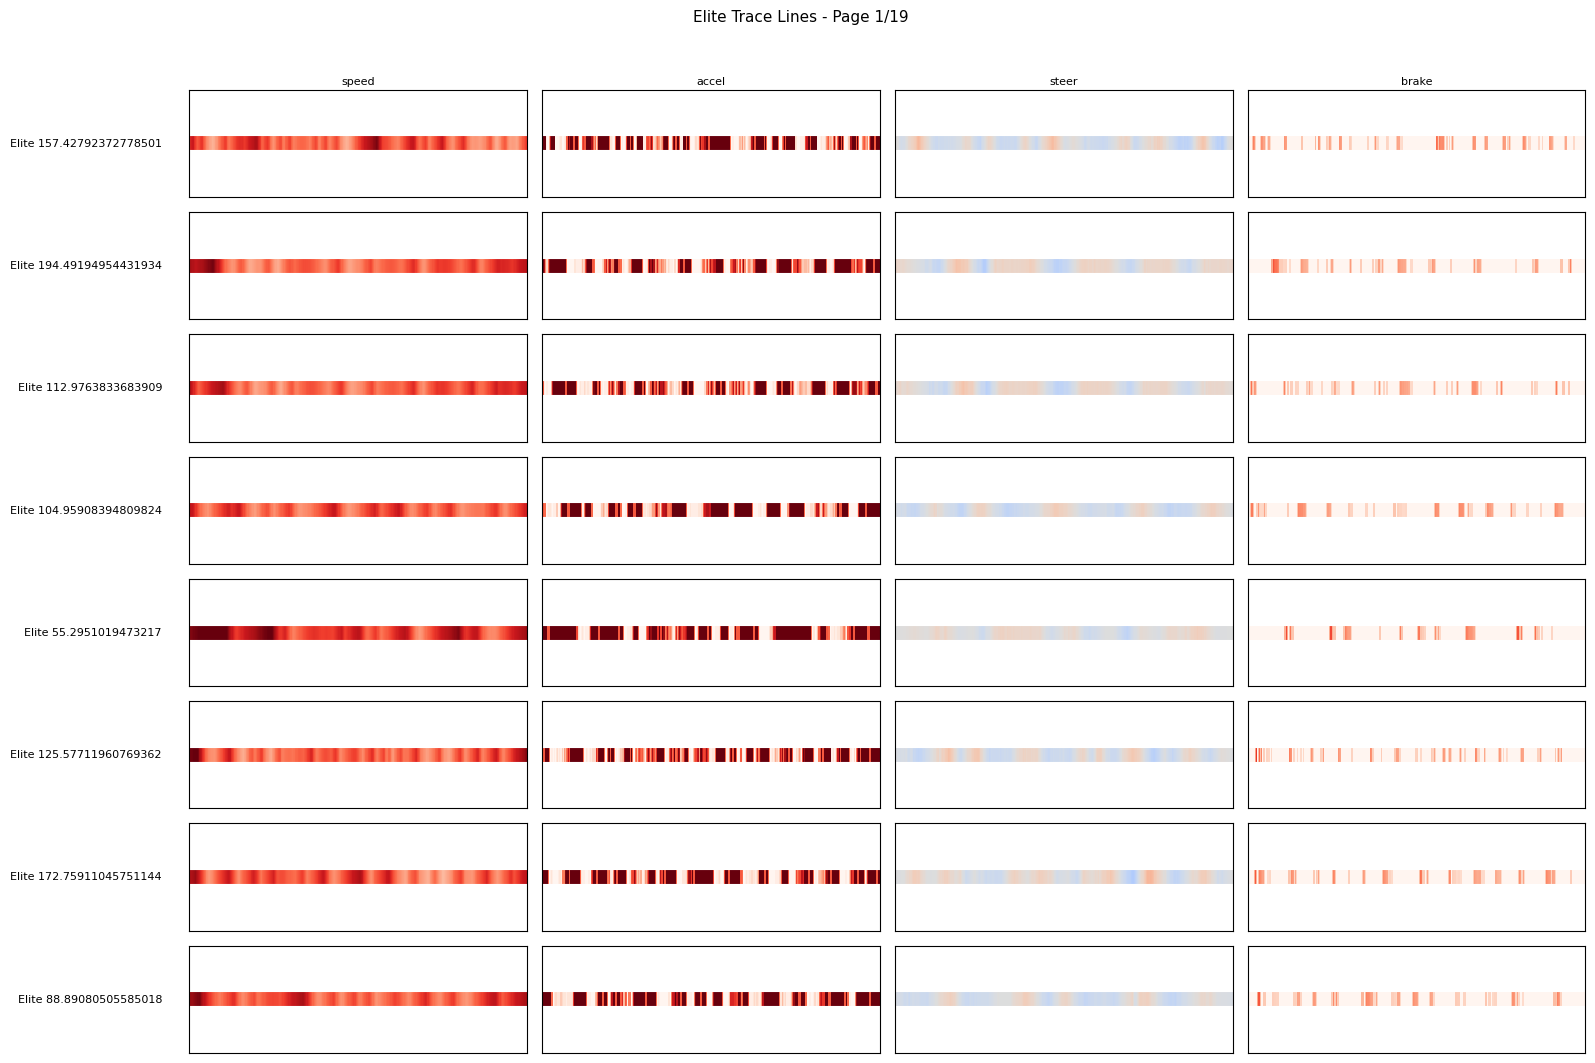

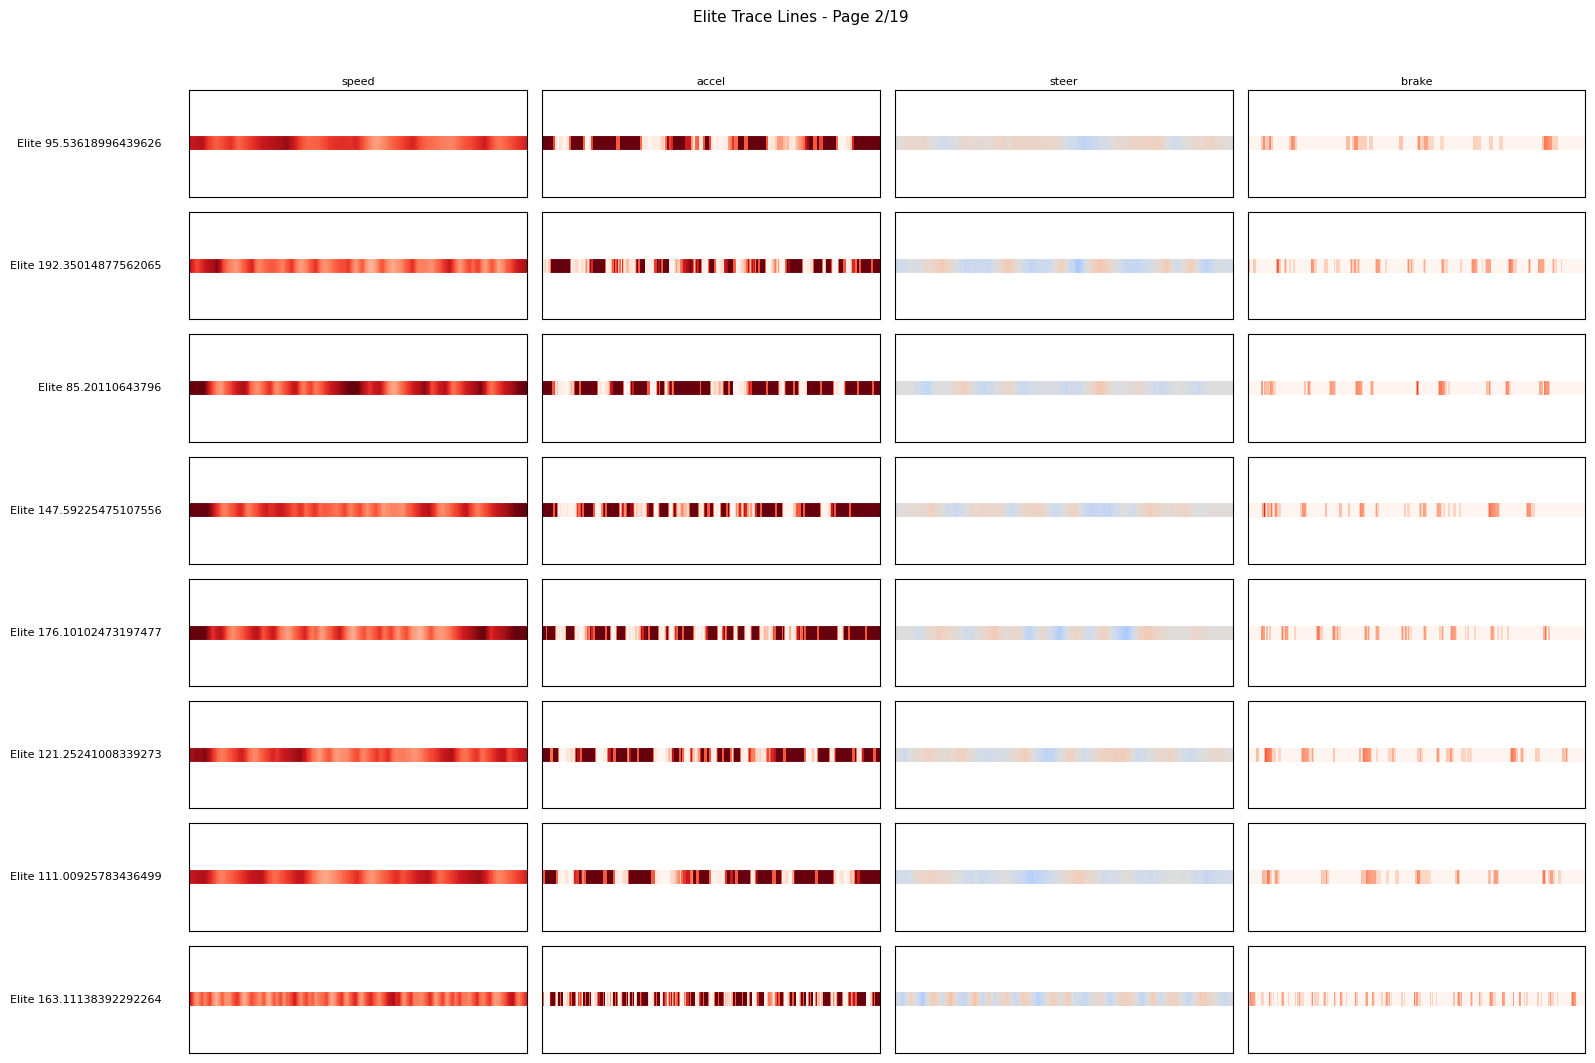

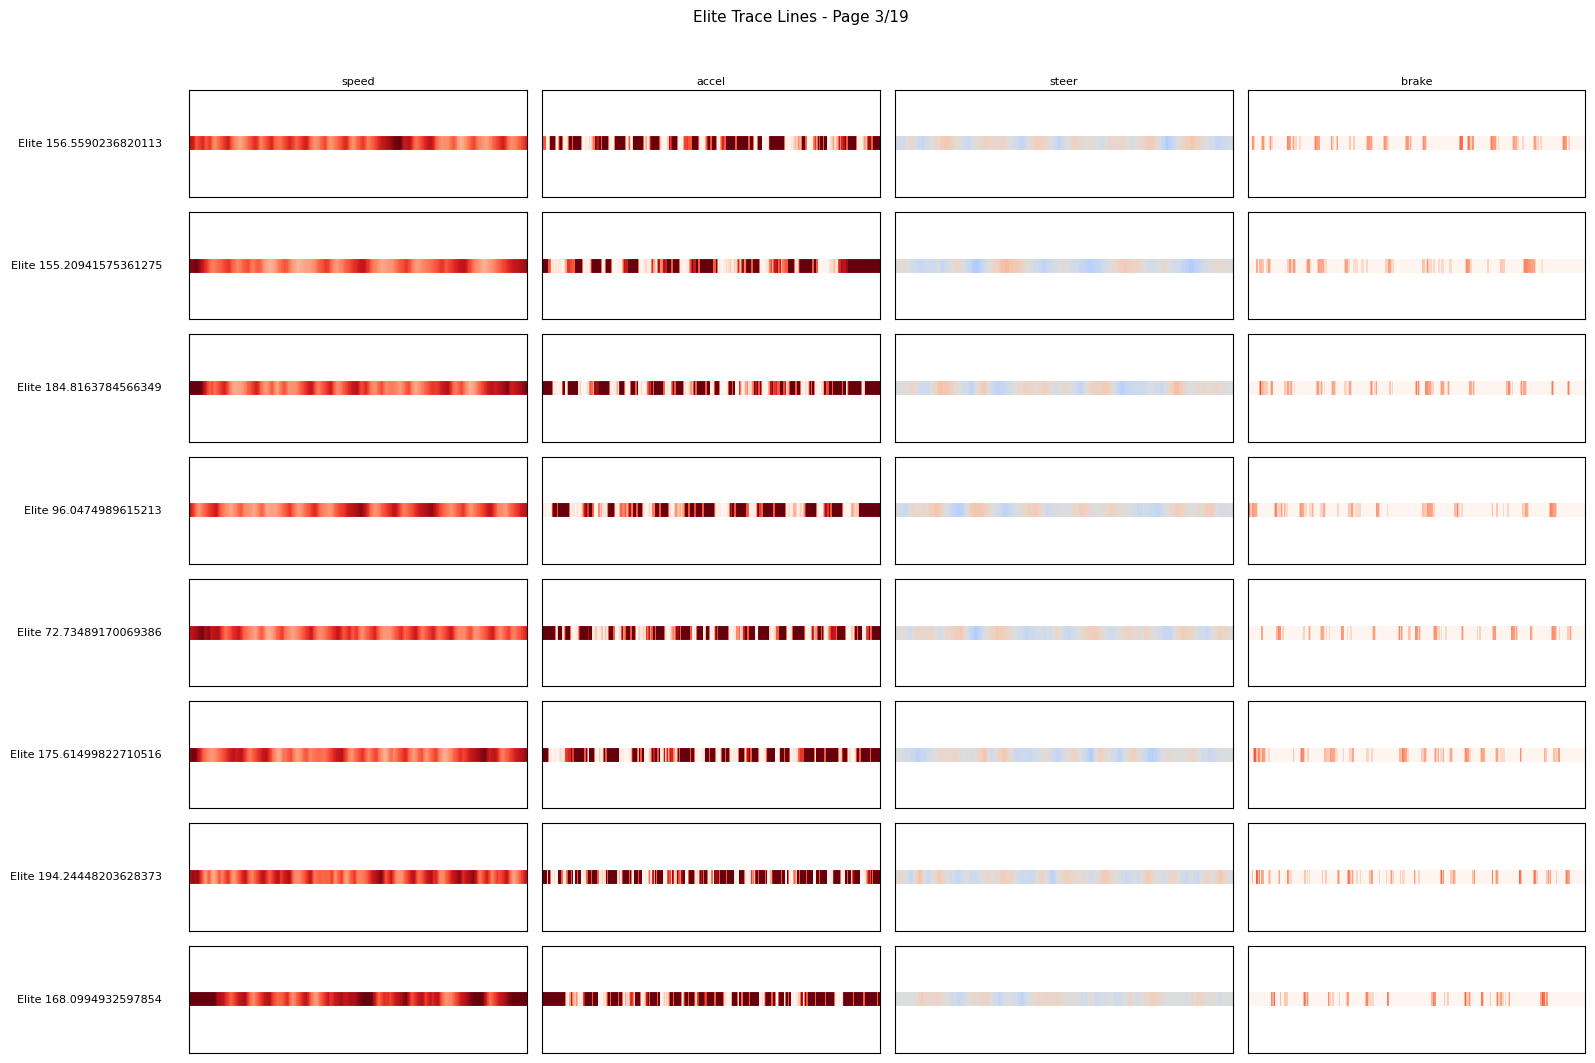

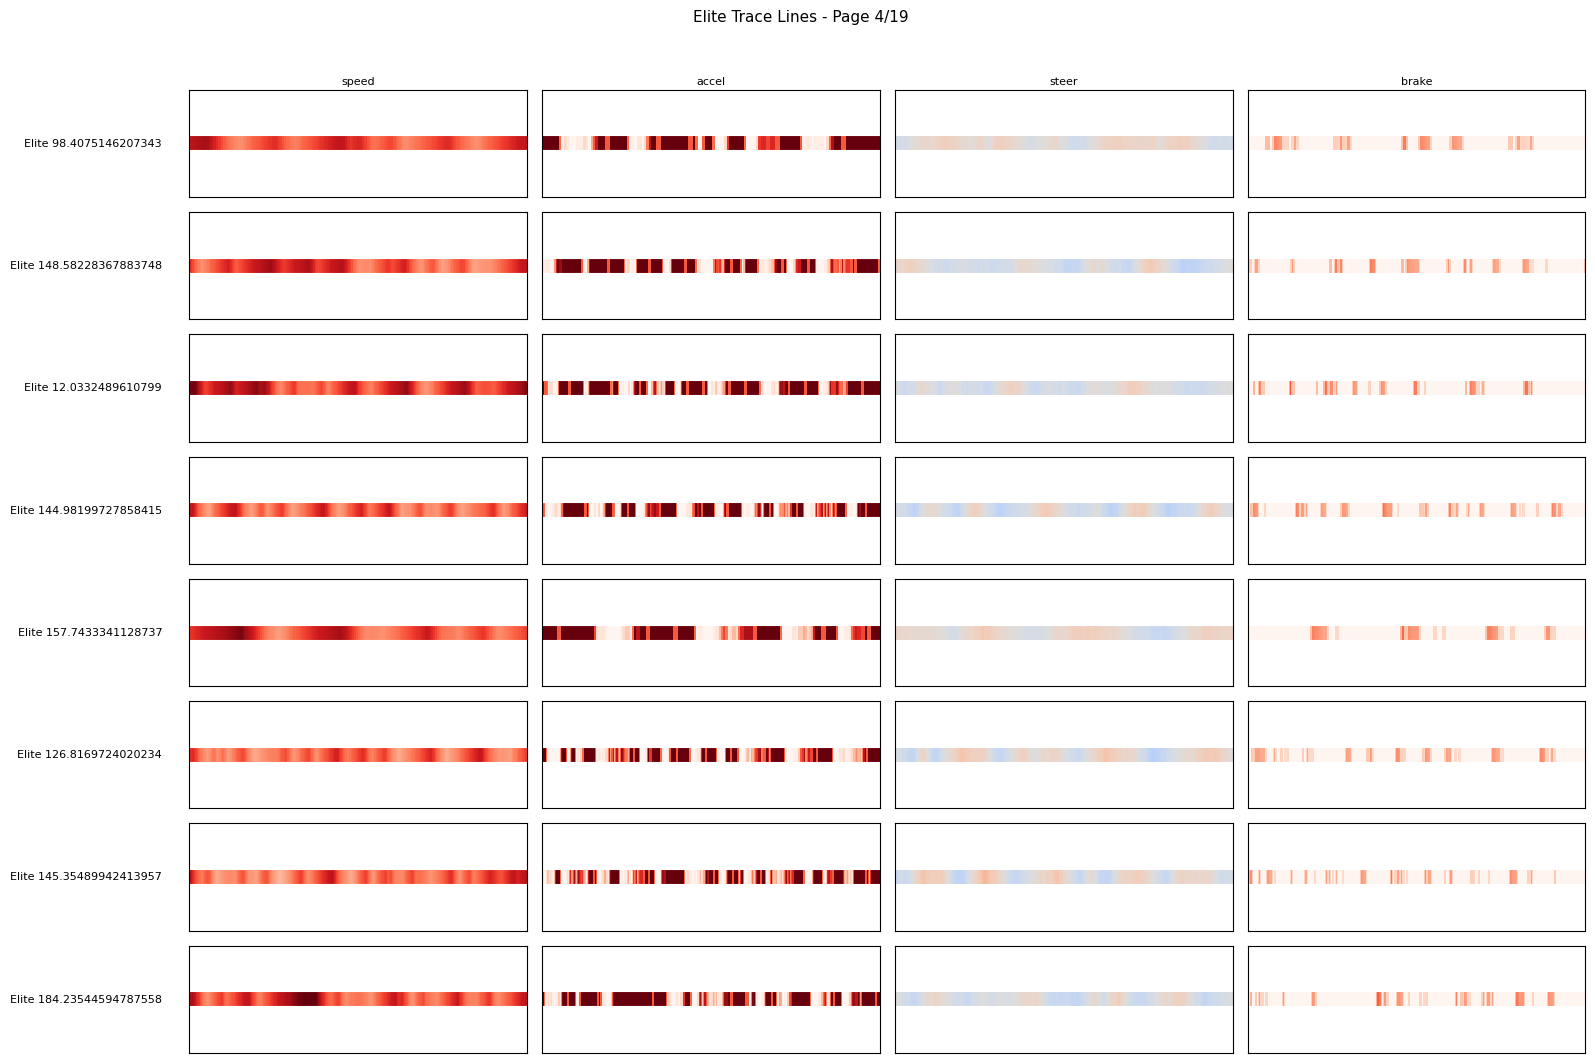

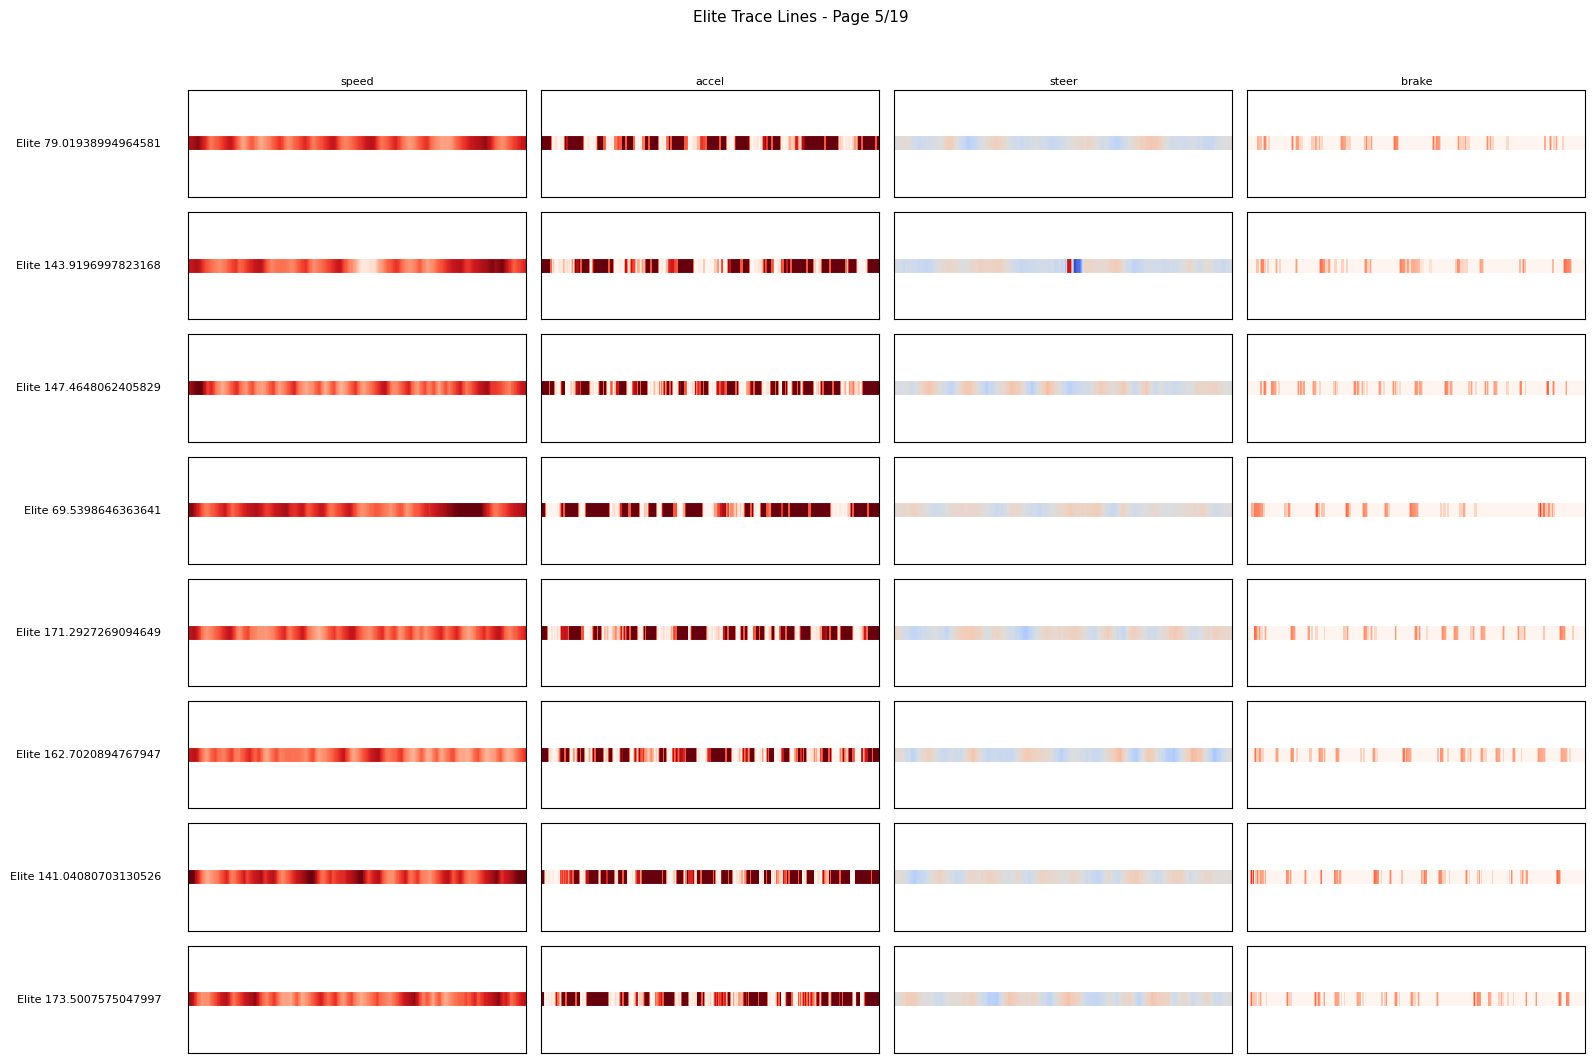

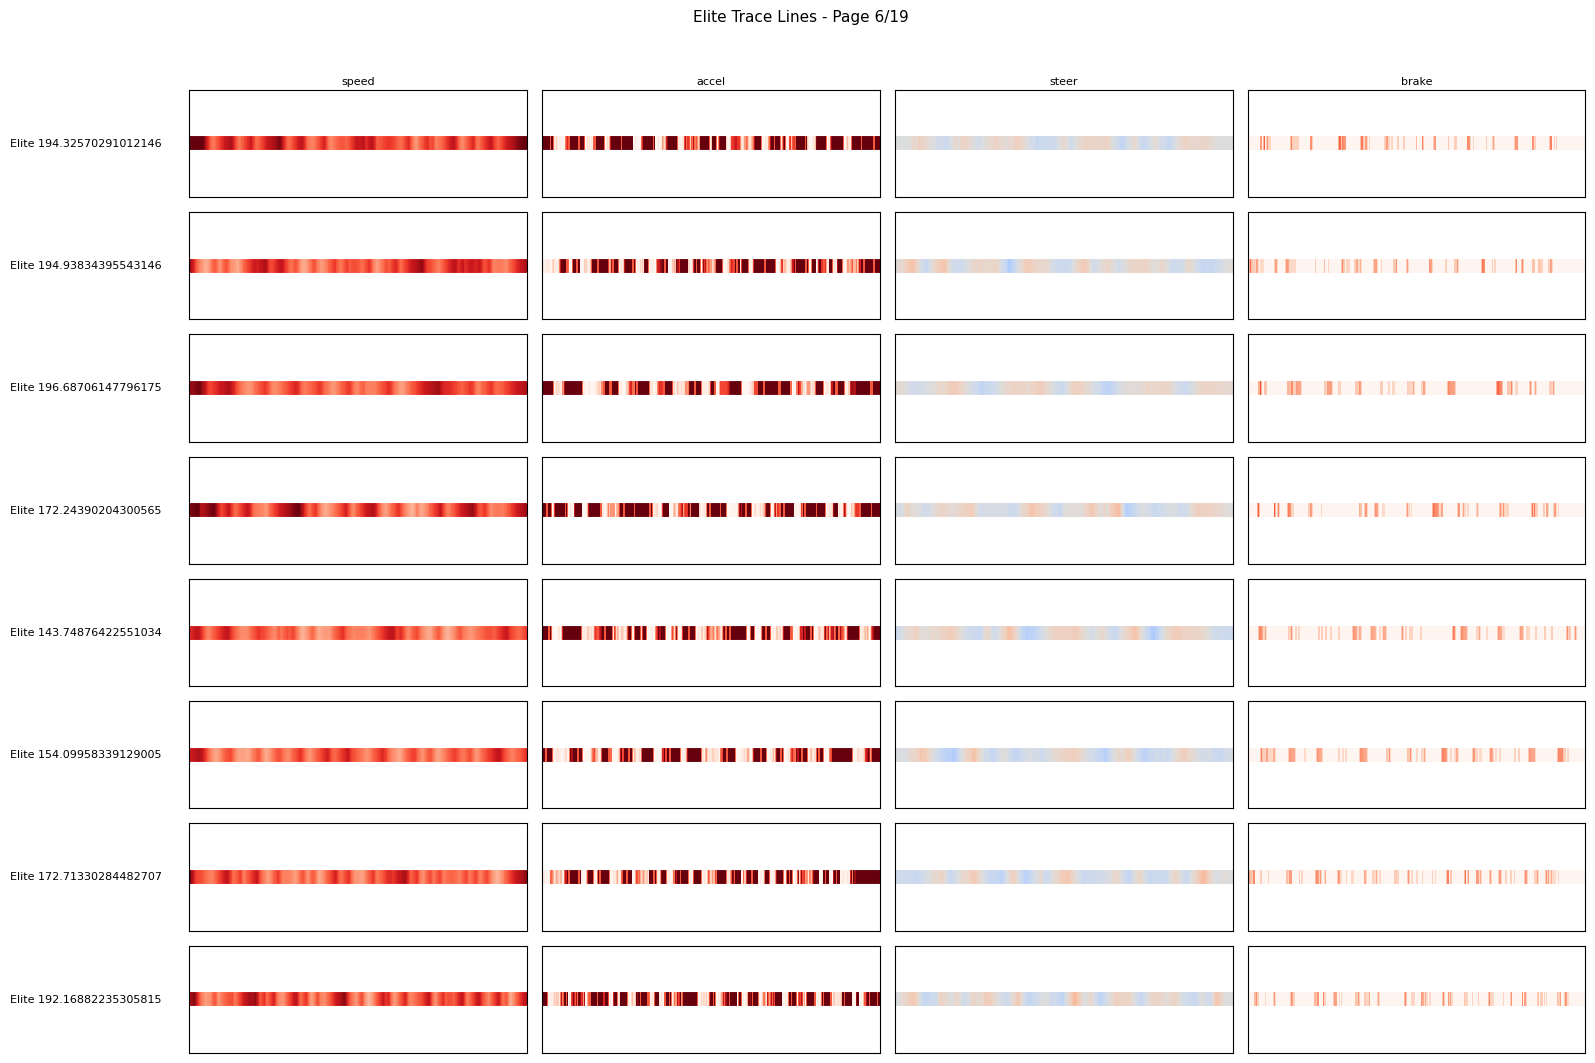

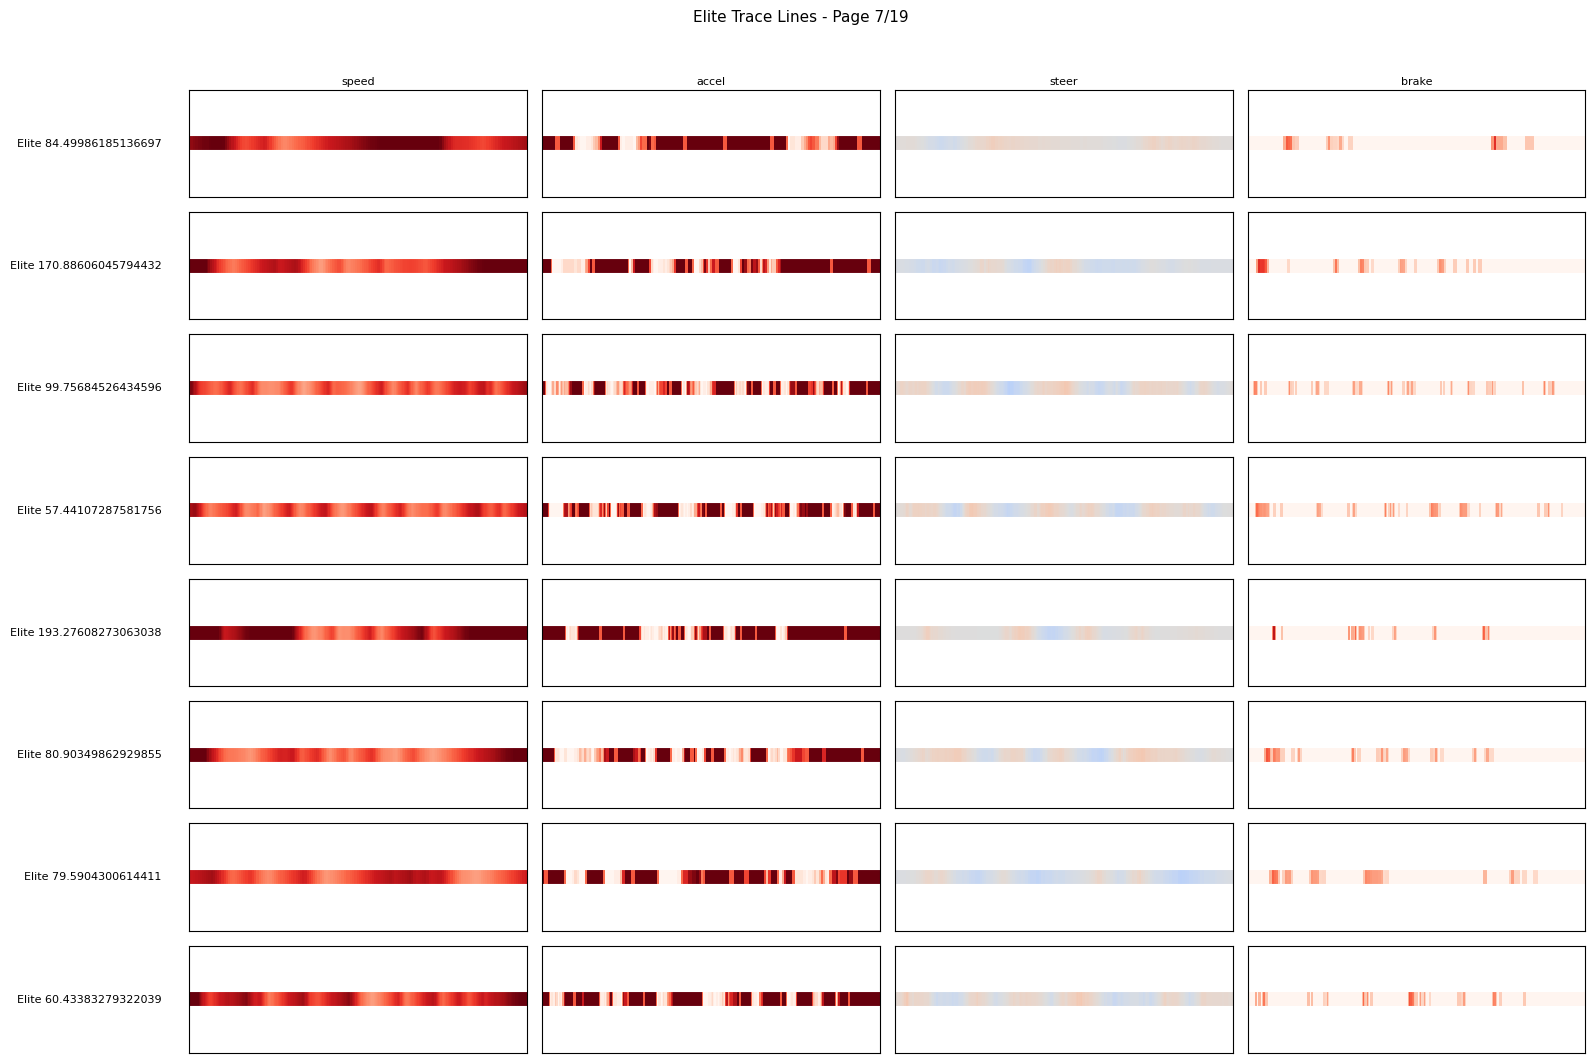

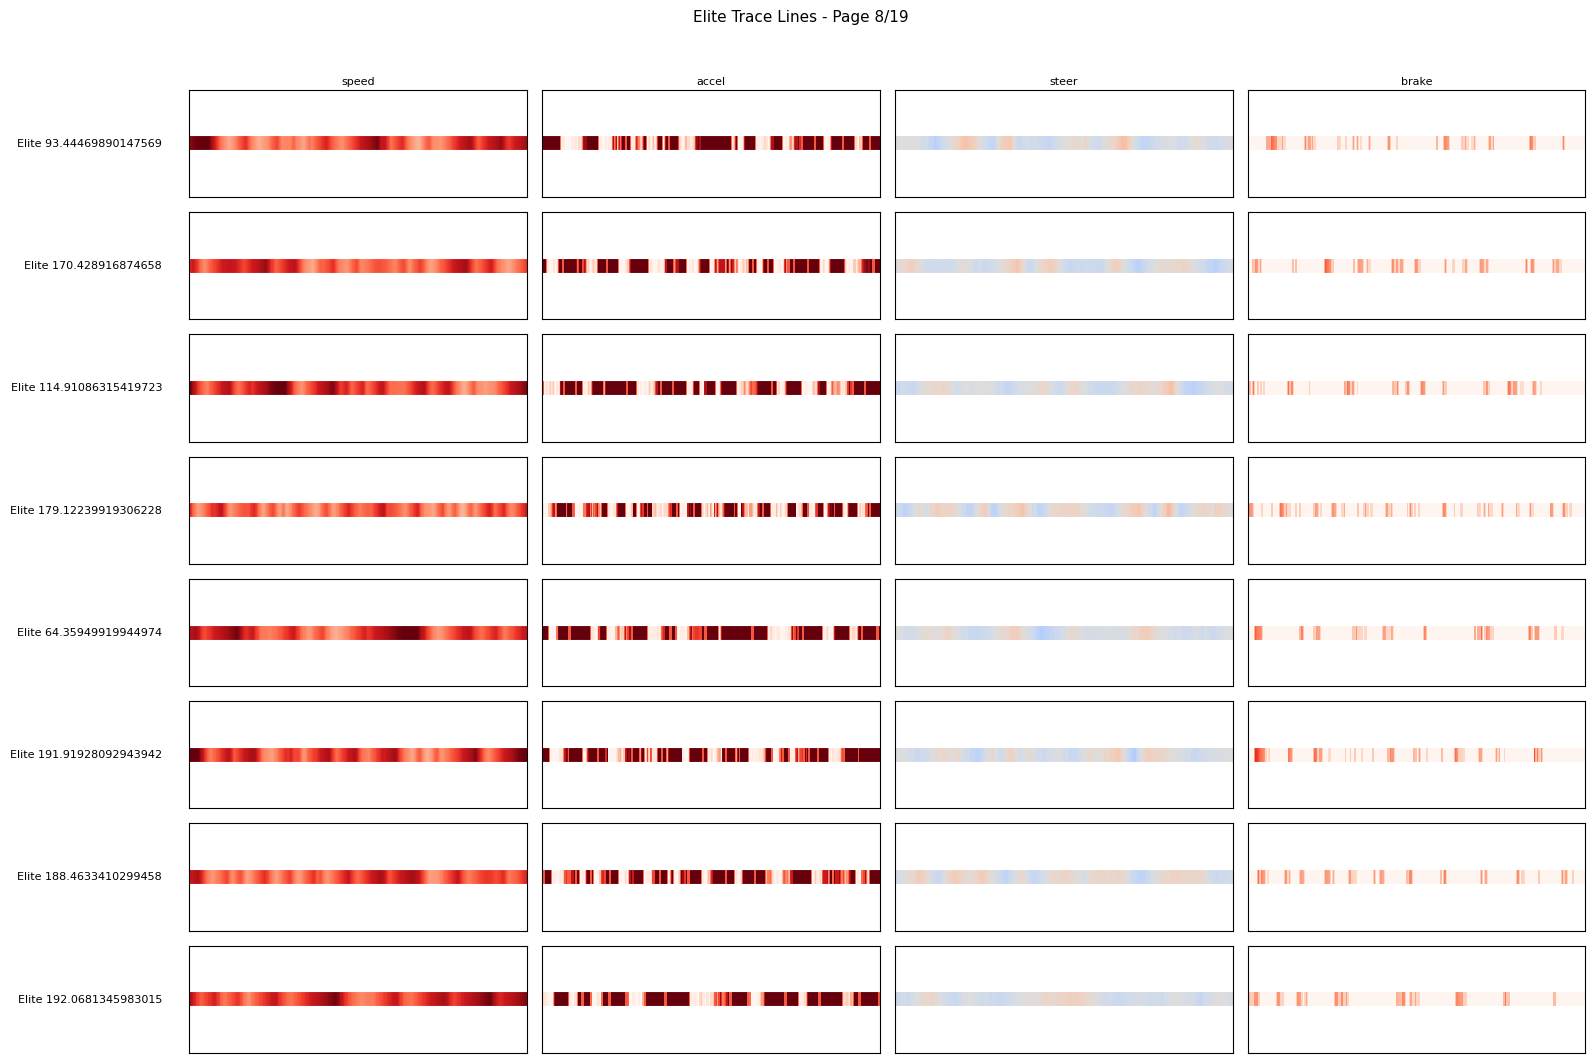

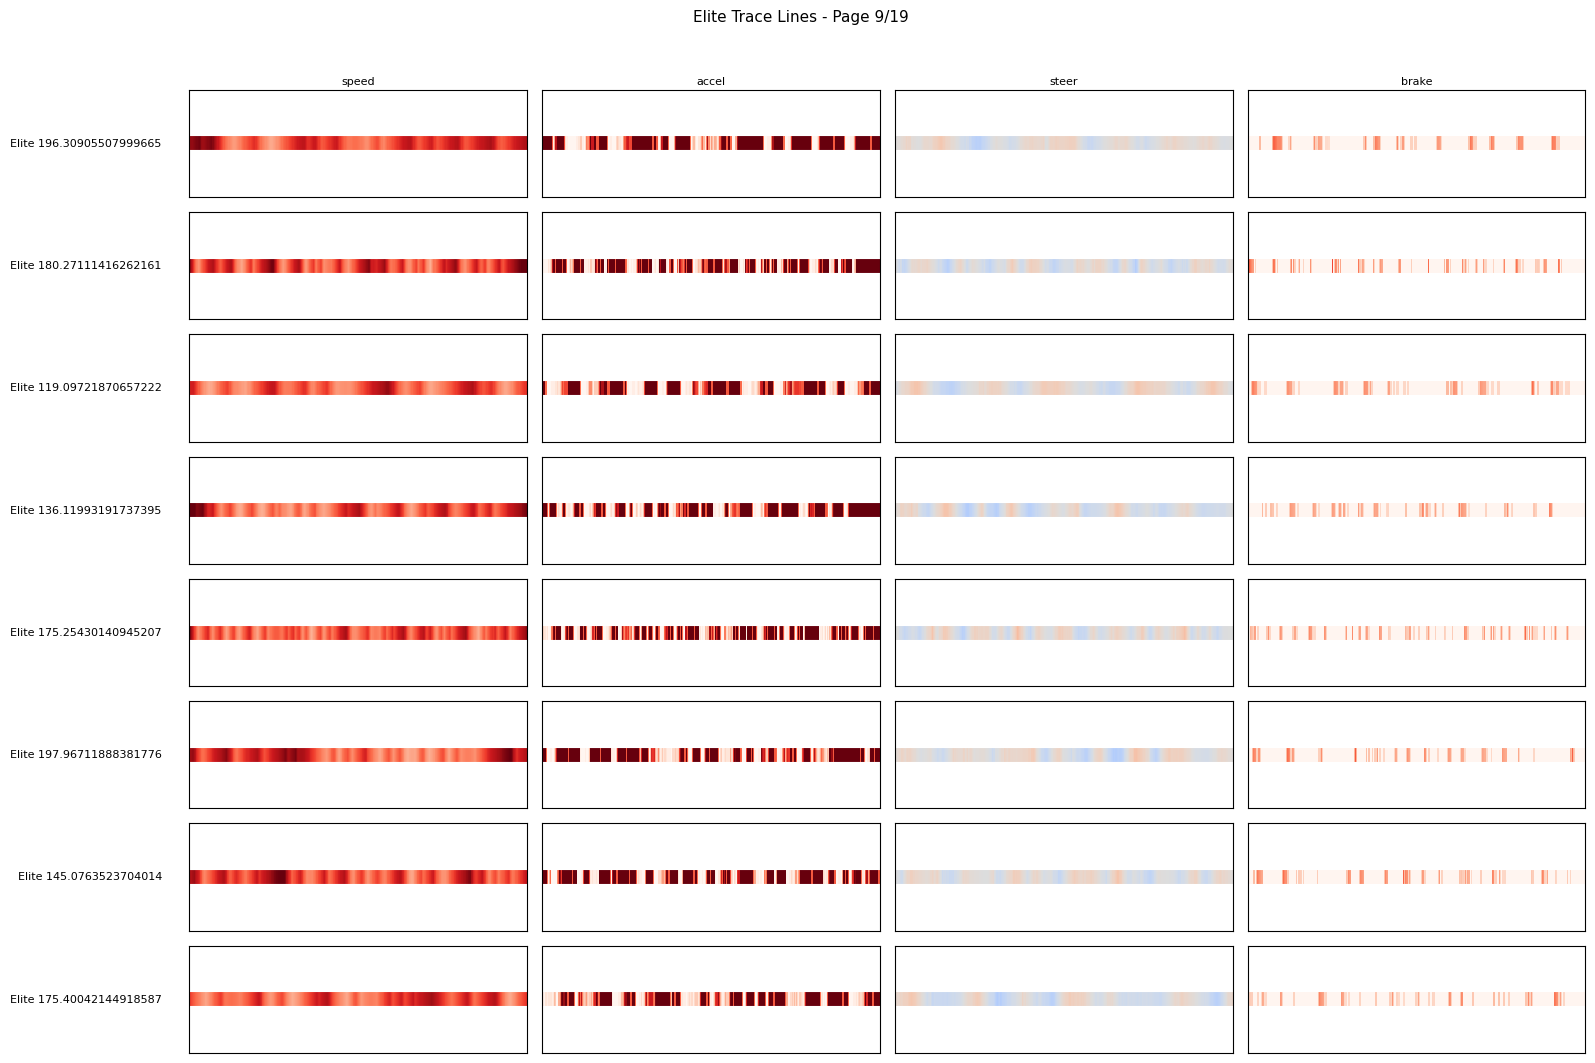

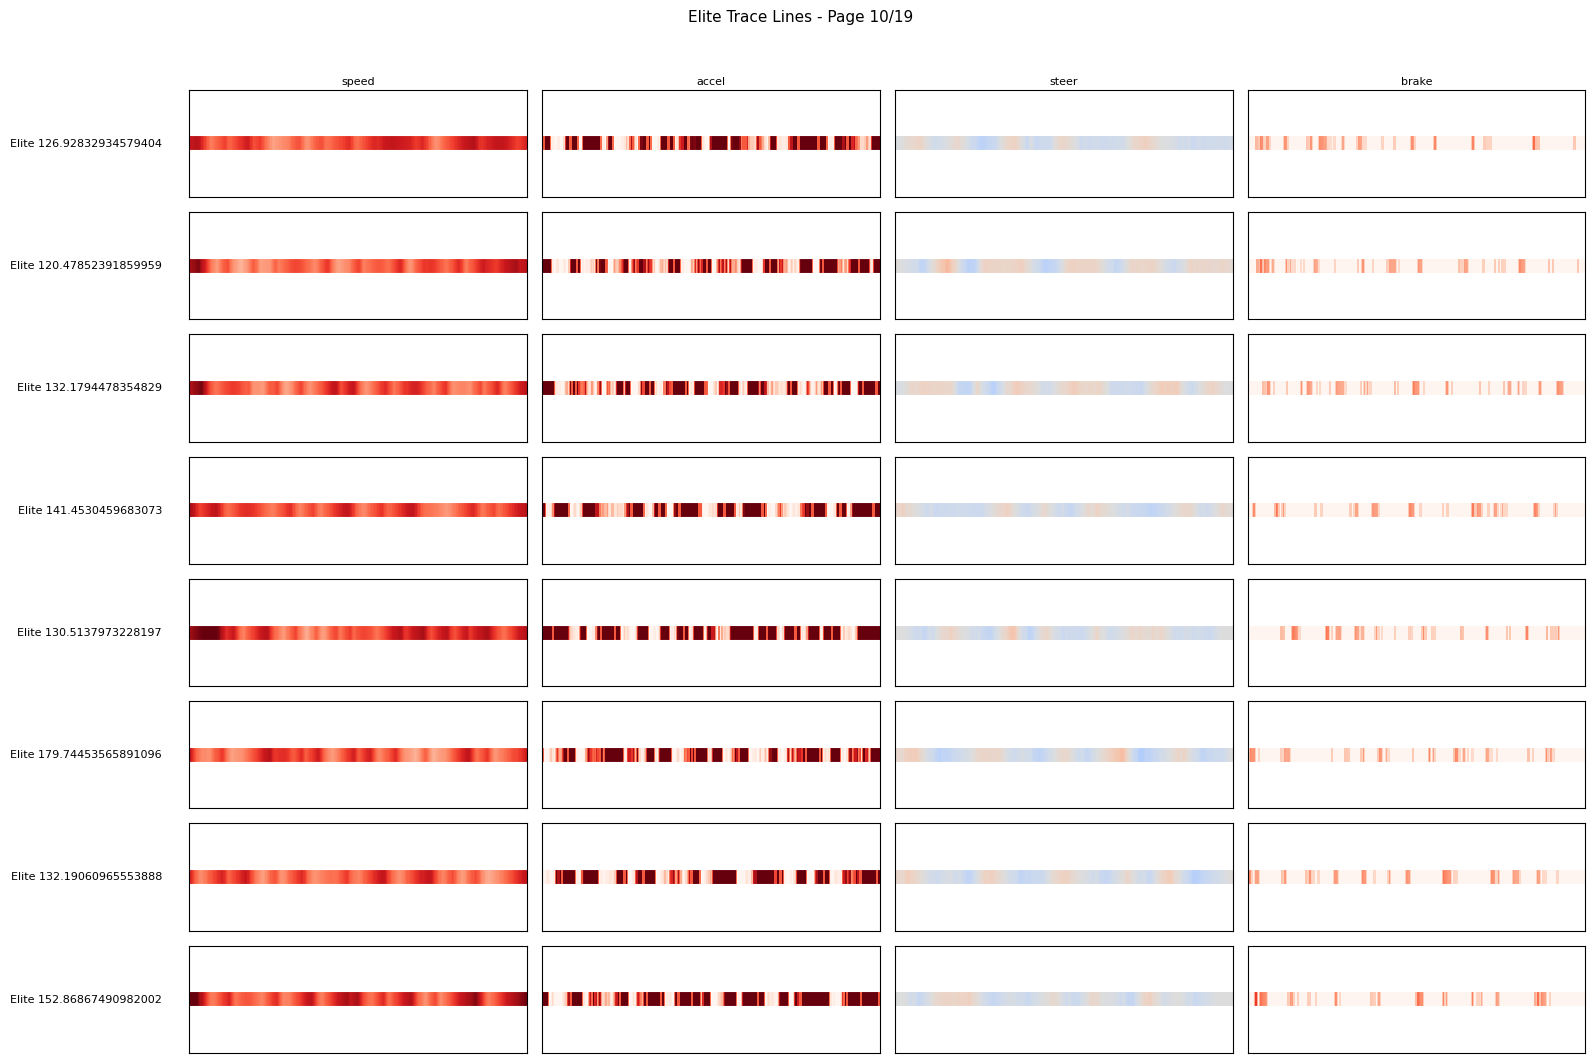

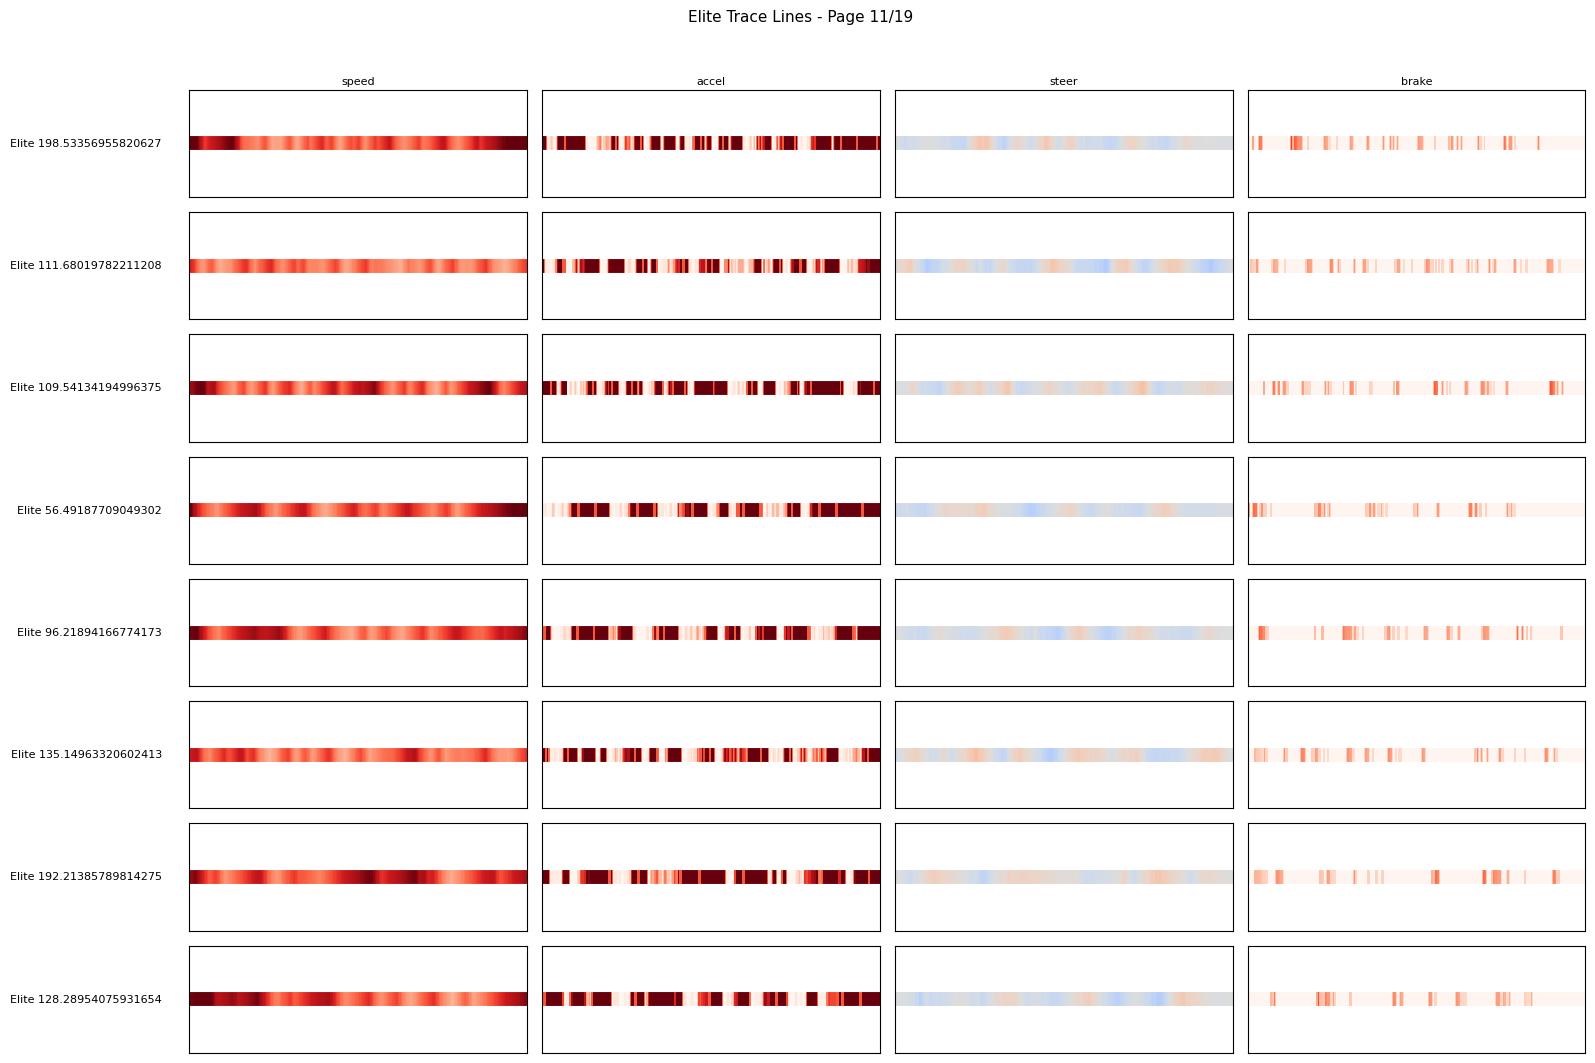

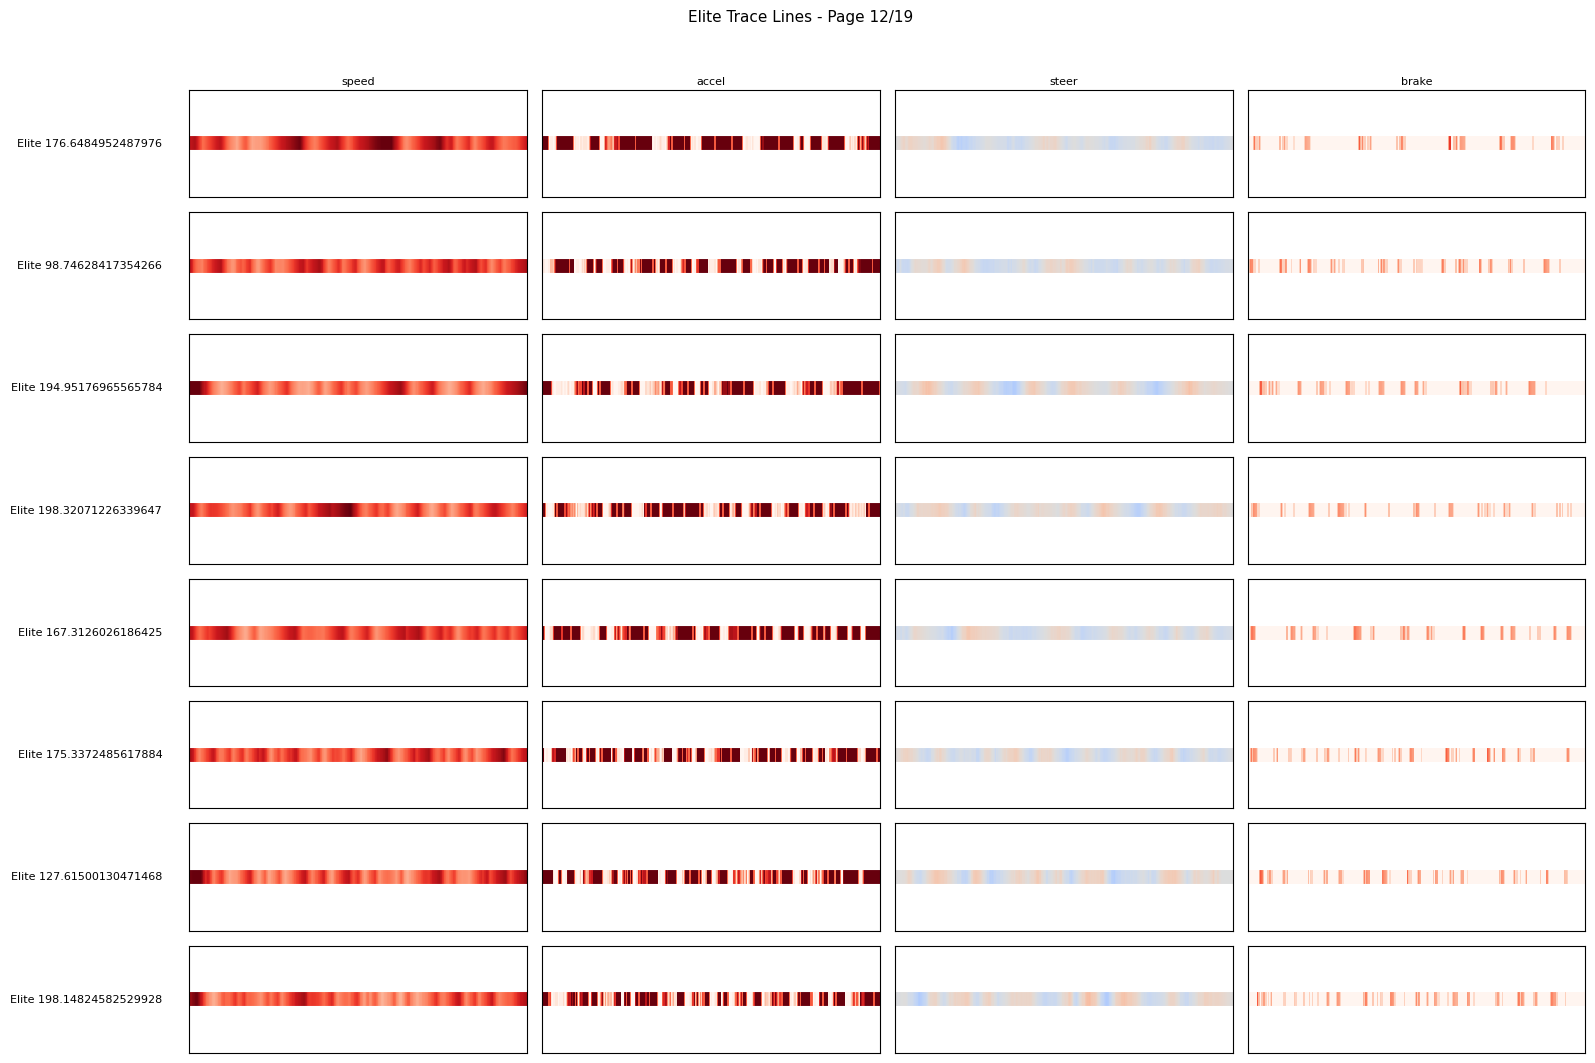

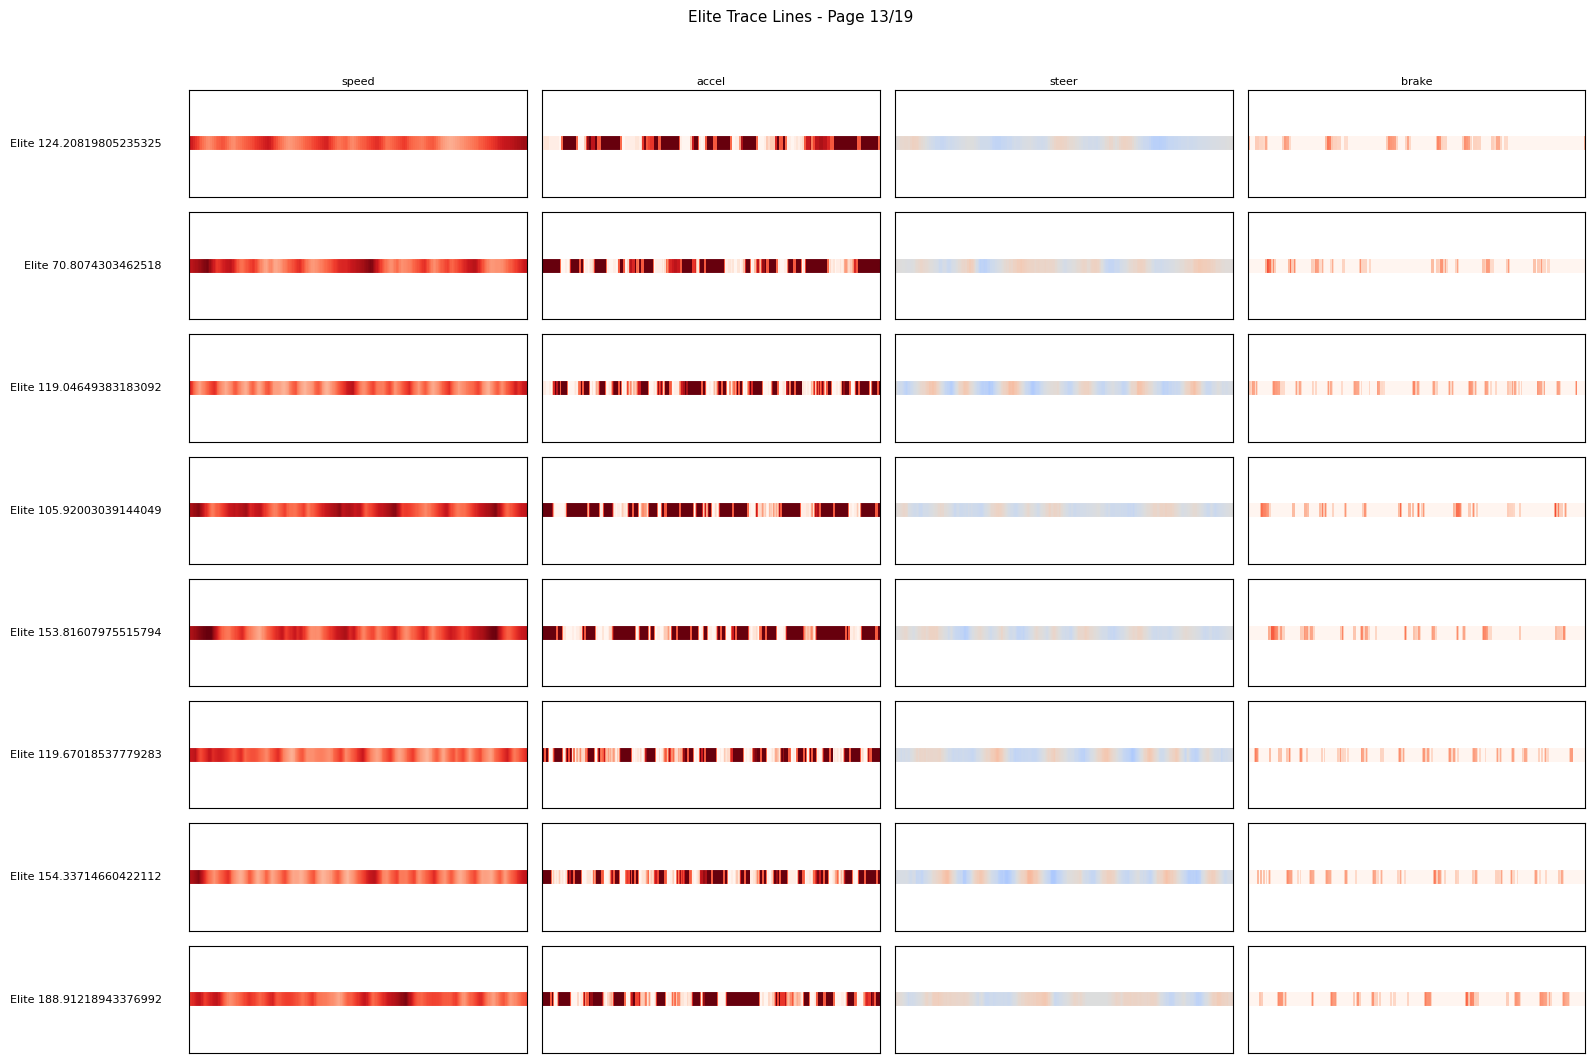

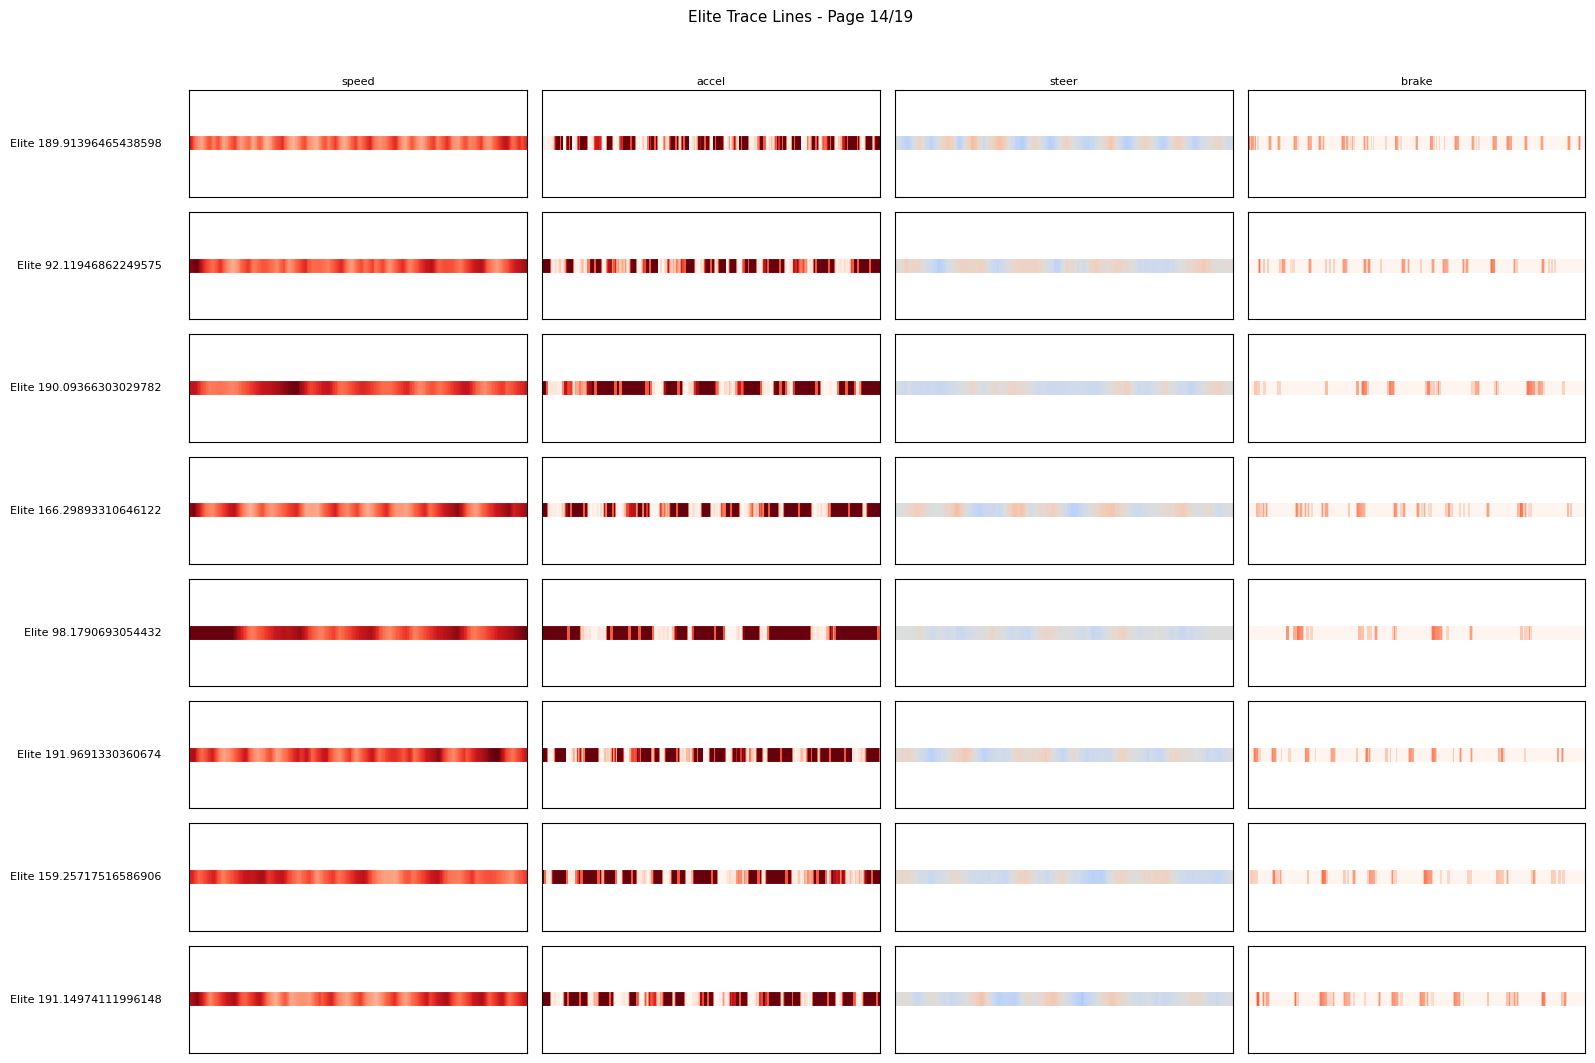

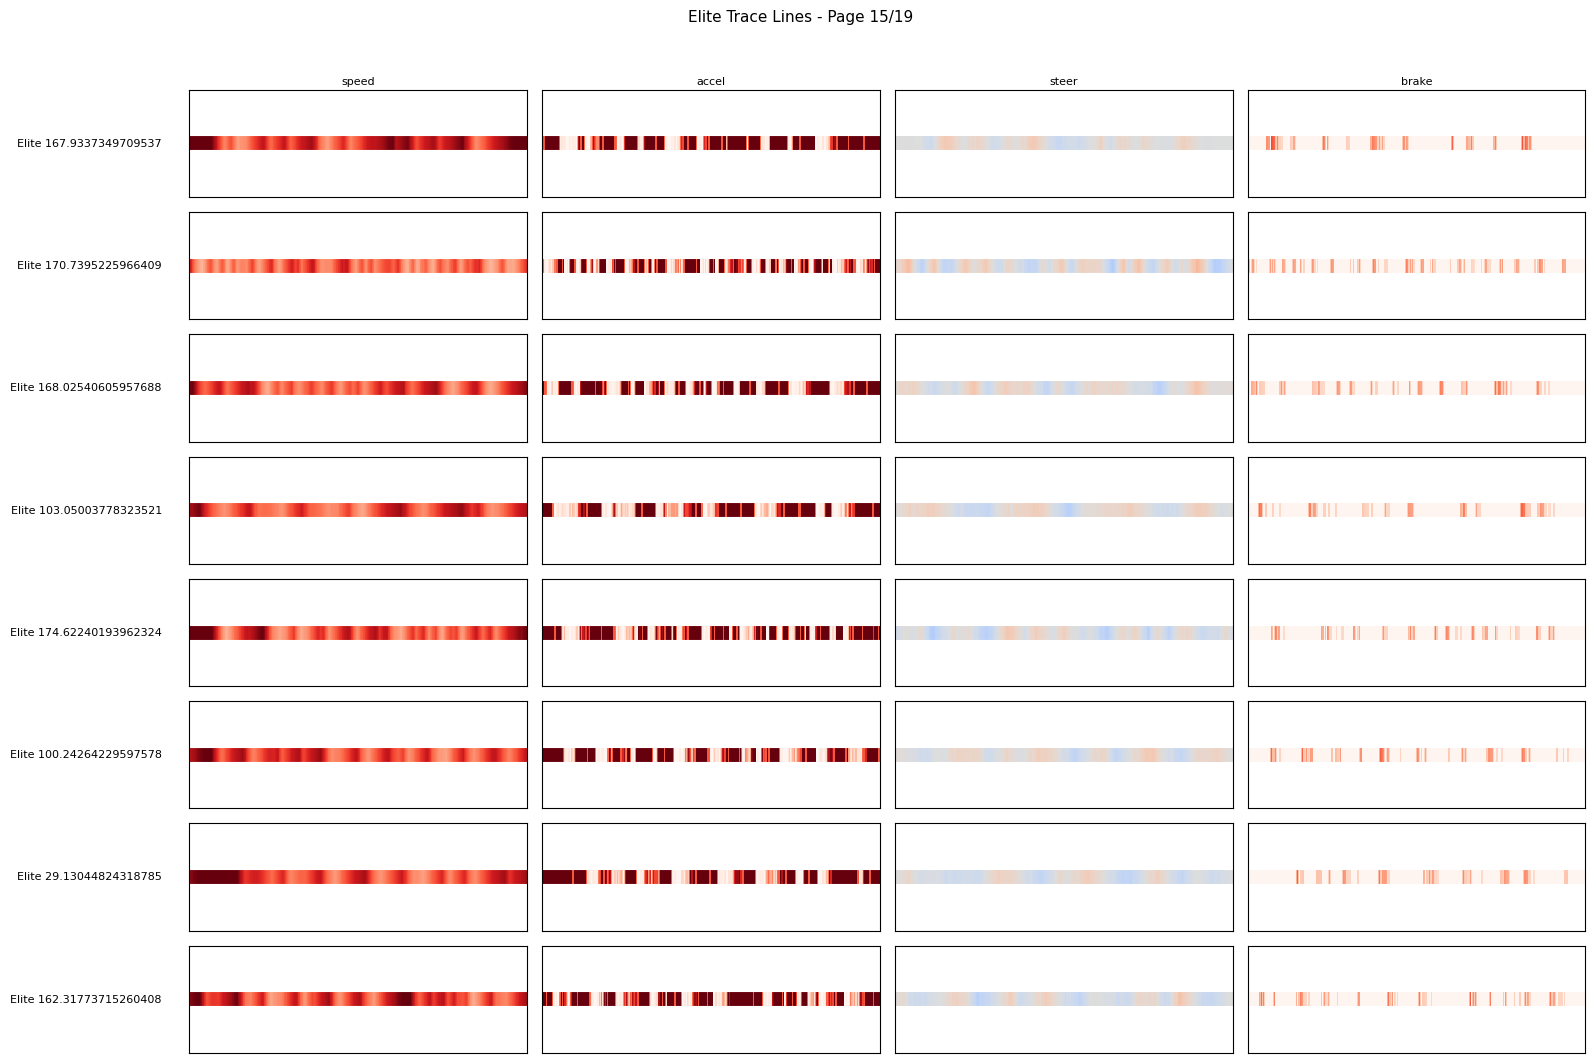

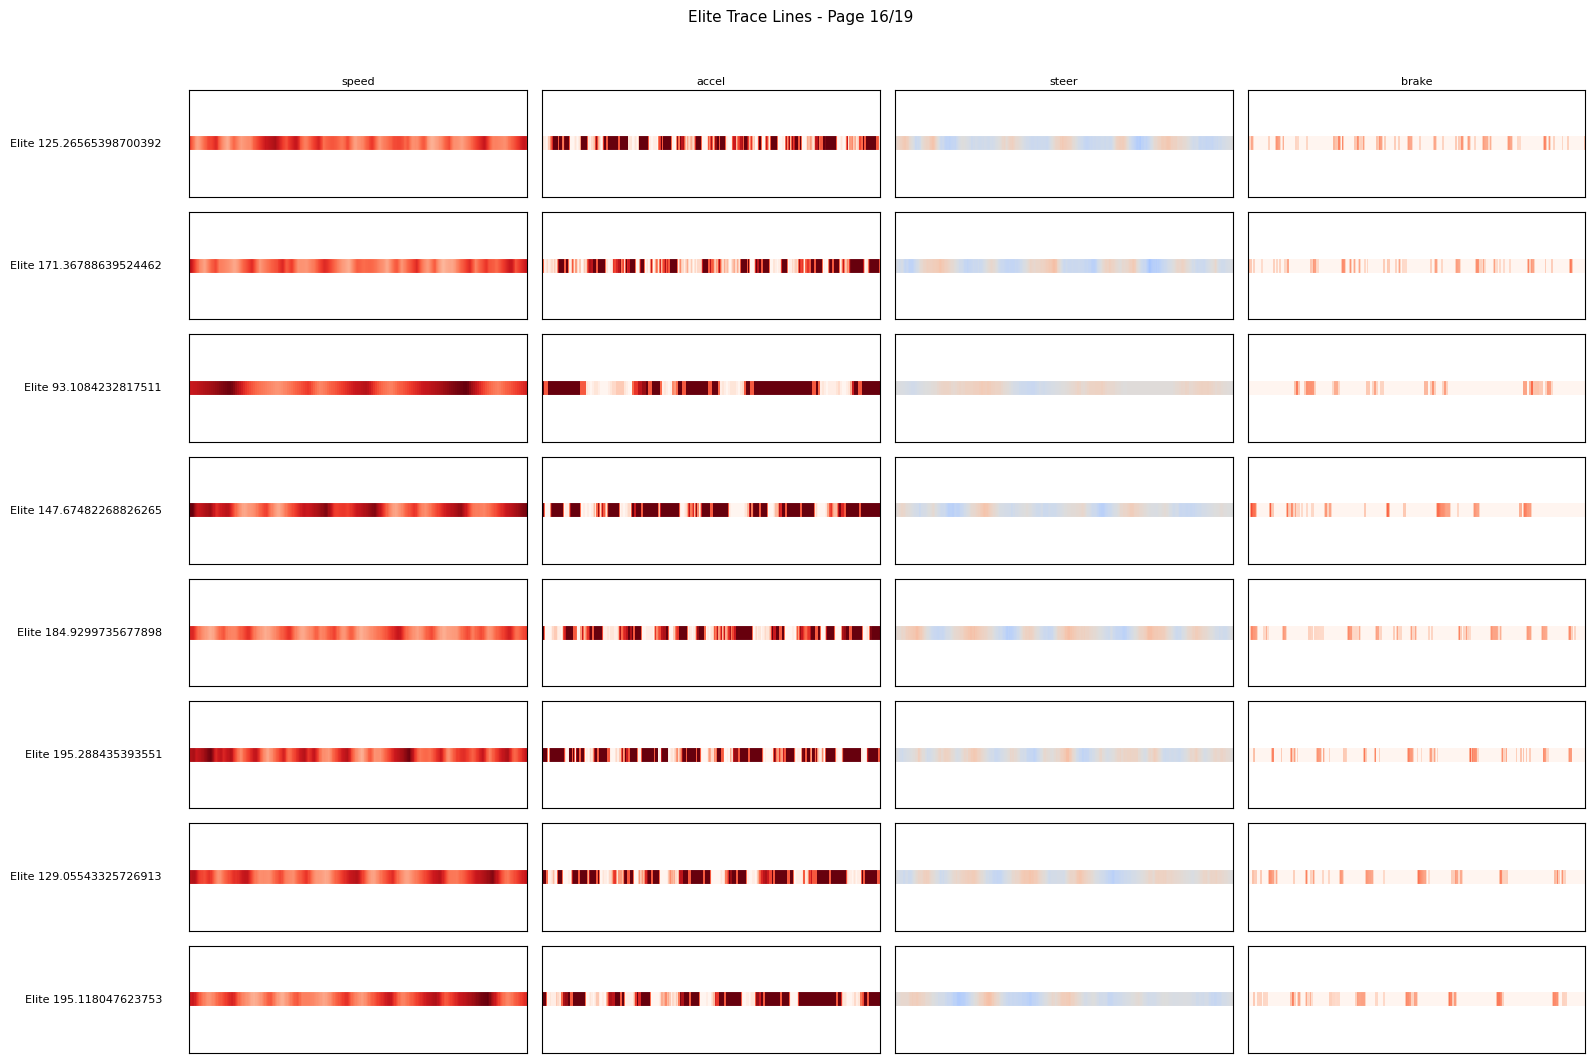

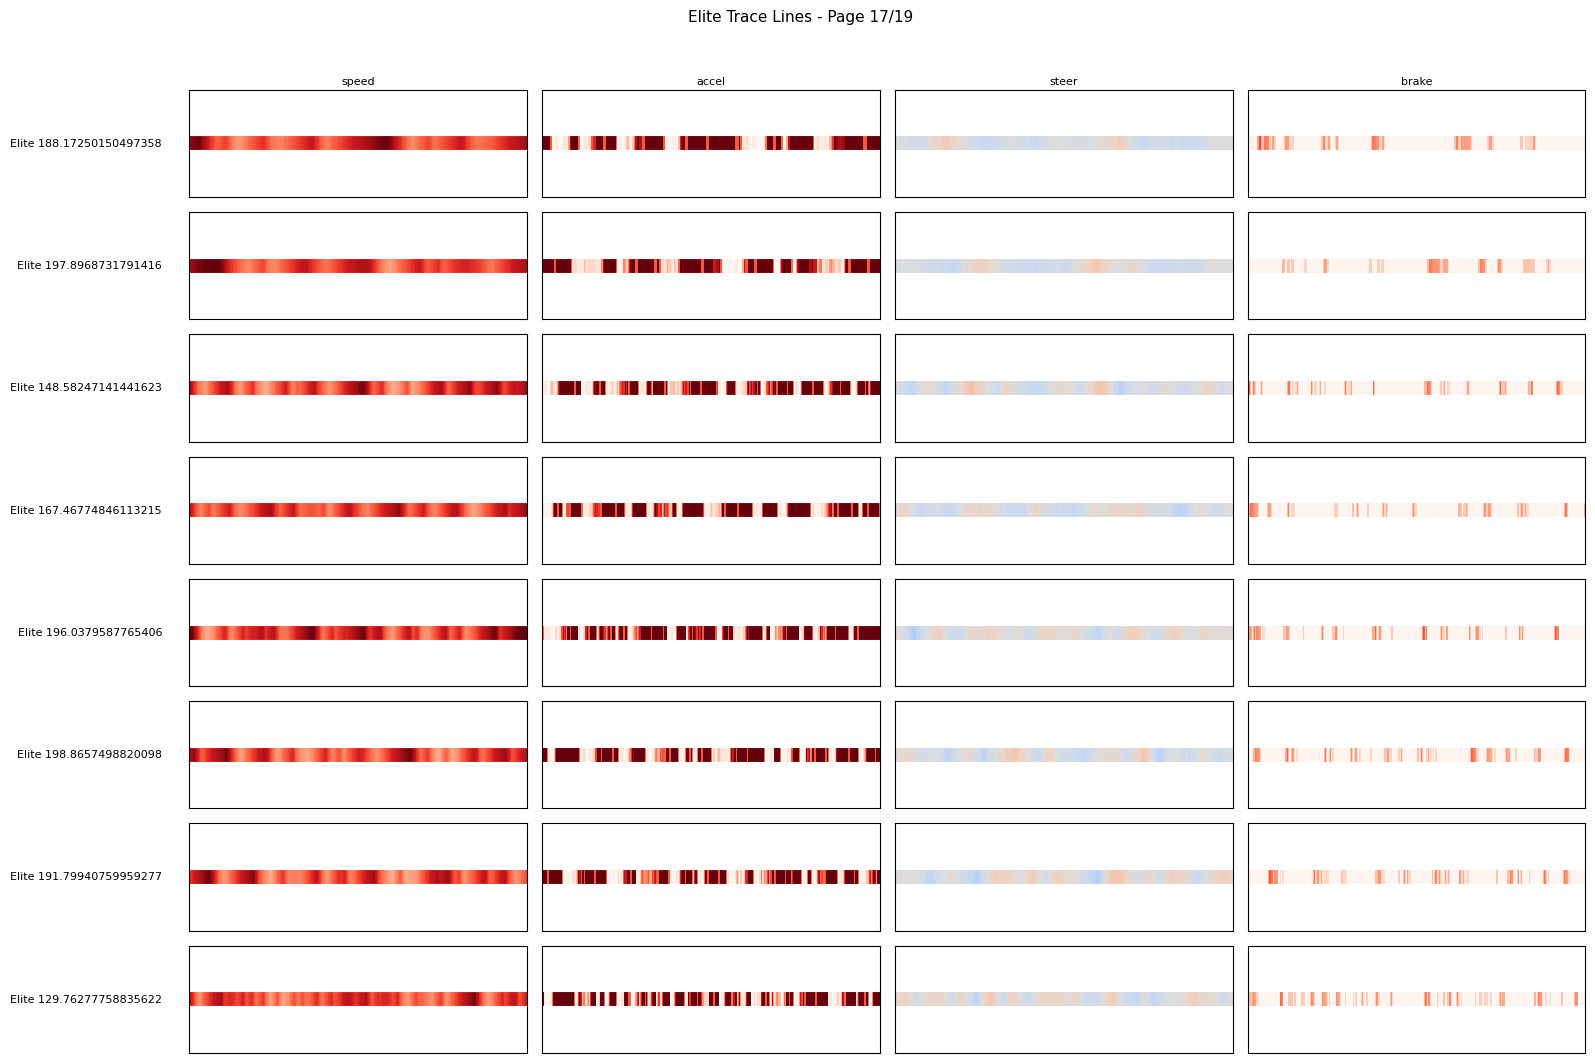

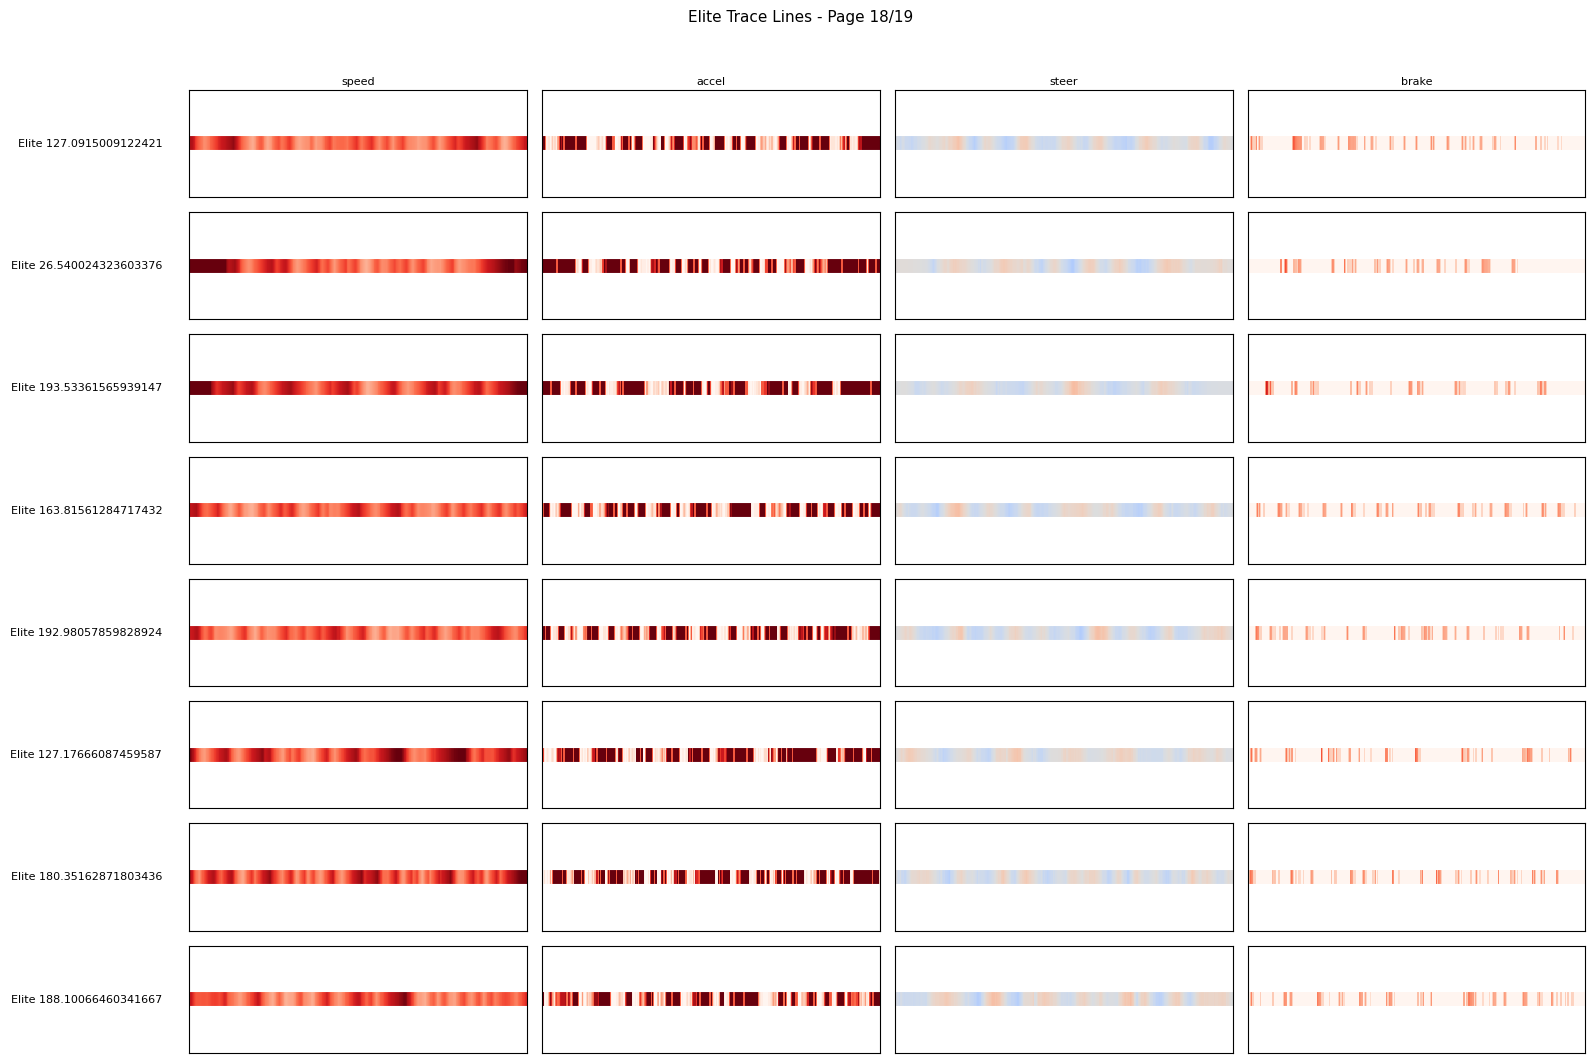

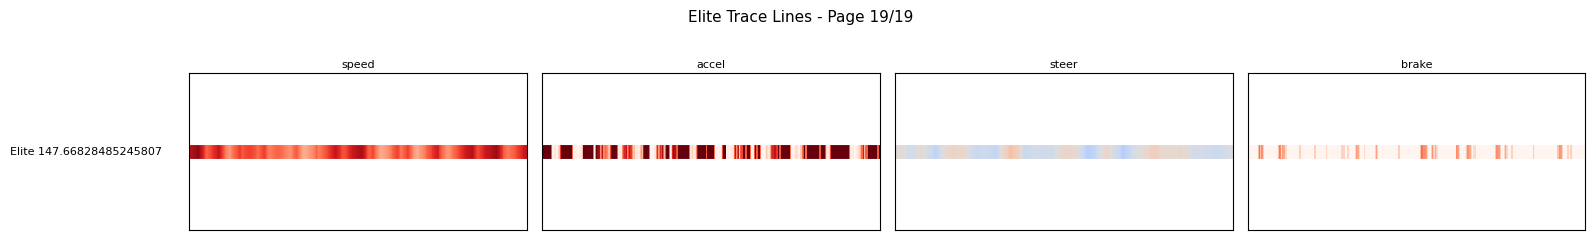

In [5]:
import math
import importlib
import numpy as np
import matplotlib.pyplot as plt

import mapelite.data_analysis.utils as analysis_utils
importlib.reload(analysis_utils)

from mapelite.data_analysis.utils import plot_trace_fixed_line

TRACE_METRICS = ["speed_trace", "accel_trace", "steer_trace", "brake_trace"]
TRACE_RANGES = {
    "speed_trace": (0, 60),
    "steer_trace": (-1, 1),
    "accel_trace": (0, 1),
    "brake_trace": (0, 1),
}
TRACE_CMAPS = {
    "speed_trace": "Reds",
    "accel_trace": "Reds",
    "steer_trace": "coolwarm",
    "brake_trace": "Reds",
}

ROWS_PER_FIGURE = 8

def _extract_trace_values(trace):
    if not trace:
        return np.array([])
    arr = np.asarray(trace, dtype=float)
    if arr.ndim != 2 or arr.shape[1] < 1:
        return np.array([])
    values = arr[:, 0]
    values = values[np.isfinite(values)]
    return values

if "id_to_traces_recon" not in globals():
    print("id_to_traces_recon is not available. Run Cell 1 first.")
else:
    elite_items = list(id_to_traces_recon.items())
    if len(elite_items) == 0:
        print("No elites found in id_to_traces_recon. Run Cell 1 first.")
    else:
        ncols = len(TRACE_METRICS)
        total_pages = math.ceil(len(elite_items) / ROWS_PER_FIGURE)
        print(f"Rendering {len(elite_items)} elites across {total_pages} figure(s)...")

        for page_num in range(total_pages):
            start_idx = page_num * ROWS_PER_FIGURE
            page = elite_items[start_idx : start_idx + ROWS_PER_FIGURE]
            nrows = len(page)

            fig, axes = plt.subplots(
                nrows,
                ncols,
                figsize=(4.0 * ncols, 1.2 * nrows + 1.2),
                squeeze=False,
            )

            for r, (elite_id, content) in enumerate(page):
                trace_data = content.get("trace_data", {})

                for c, metric in enumerate(TRACE_METRICS):
                    ax = axes[r, c]
                    values = _extract_trace_values(trace_data.get(metric, None))
                    title = metric.replace("_trace", "")

                    if values.size >= 2:
                        plot_trace_fixed_line(
                            ax,
                            values,
                            line_length=1.0,
                            y=0.0,
                            title=title if r == 0 else None,
                            cmap=TRACE_CMAPS.get(metric, "Reds"),
                            color_range=TRACE_RANGES.get(metric),
                            linewidth=10,
                            show_colorbar=False,
                        )
                    else:
                        ax.set_axis_off()
                        if r == 0:
                            ax.set_title(title, fontsize=8, pad=4)
                        ax.text(
                            0.5,
                            0.5,
                            "missing data",
                            ha="center",
                            va="center",
                            transform=ax.transAxes,
                            fontsize=7,
                        )

                    if c == 0:
                        ax.text(
                            -0.08,
                            0.5,
                            f"Elite {elite_id}",
                            transform=ax.transAxes,
                            ha="right",
                            va="center",
                            fontsize=8,
                        )

            fig.suptitle(f"Elite Trace Lines - Page {page_num + 1}/{total_pages}", fontsize=11)
            plt.tight_layout(rect=[0, 0, 1, 0.96])
            plt.show()